# Stage 11 — Complex neural network (temporal)

A Bai-et-al.-2018-style Temporal Convolutional Network (TCN) — dilated
causal 1D convolutions stacked into residual blocks — wrapped in the
Stage 4 `Model` protocol and registered through the Stage 9 registry.

The pedagogical payoff is the **six-row ablation table** (Cell 6) — one
row per model family, all evaluated on the same held-out tail of the
weather-only feature table.  Intent §Demo moment names the table as
*the* canonical Stage 11 artefact: a facilitator can read it and tell a
coherent story from naive through linear through SARIMAX through scipy
parametric through the simple MLP to the new TCN.  Intent §Purpose adds
the analytical stake: this is where the neural approach finally has a
genuine shot at beating the linear and classical models, *because*
temporal dependencies are in the model's field of view.

- **Intent:** `docs/intent/11-complex-nn.md`.
- **Plan:** `docs/plans/active/11-complex-nn.md` (moved to `completed/`
  at T8).
- **Previous stage:** Stage 10 simple MLP — the training-loop +
  reproducibility scaffold the TCN inherits.

Plan decisions applied here: D1 (TCN architecture; CUDA-sized defaults
overridden to a tiny CPU recipe so the notebook is a few minutes on a
4-core laptop), D2 (`seq_len = 168` weekly cycle anchor; the receptive
field validator catches degenerate combinations), D3 (Pattern A
exogenous handling — every weather column rides inside the sequence
window), D4 (shared training loop in `_training.py`), D6 (four-stream
seeding inherited from Stage 10 D7'), D9 (cold-start per fold), D10
(single ablation table; no bar chart, no scatter, no receptive-field
diagram), D11 (notebook-inline predict-only loop — *not* a standalone
helper module), D12 (single-holdout regime; the last 20 % of the
feature table).

The ablation cell is **predict-only**.  AC-5 forbids re-fitting any
already-registered run; every metric in the table is computed by
`registry.load(run_id) -> model.predict(X_holdout)` and metric
composition.  `harness.evaluate` and `compare_on_holdout` re-fit per
fold and are deliberately *not* called from the ablation cell.


In [1]:
# T7 Cell 1 — Bootstrap: walk up to the repo root so
# ``from bristol_ml import ...`` and Hydra's ``conf/`` both resolve,
# then import every Stage-4 / Stage-7 / Stage-8 / Stage-9 / Stage-10 /
# Stage-11 surface the notebook touches.

import os
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
import torch  # noqa: E402
from IPython.display import clear_output, display  # noqa: E402

from bristol_ml import load_config, registry  # noqa: E402
from bristol_ml.evaluation import plots  # noqa: E402
from bristol_ml.evaluation.metrics import METRIC_REGISTRY  # noqa: E402
from bristol_ml.features import assembler  # noqa: E402
from bristol_ml.models.linear import LinearModel  # noqa: E402
from bristol_ml.models.naive import NaiveModel  # noqa: E402
from bristol_ml.models.nn.mlp import NnMlpModel  # noqa: E402
from bristol_ml.models.nn.temporal import NnTemporalModel  # noqa: E402
from bristol_ml.models.sarimax import SarimaxModel  # noqa: E402
from bristol_ml.models.scipy_parametric import ScipyParametricModel  # noqa: E402
from conf._schemas import (  # noqa: E402
    LinearConfig,
    NaiveConfig,
    NnMlpConfig,
    NnTemporalConfig,
    SarimaxConfig,
    ScipyParametricConfig,
)

# Apply the Okabe-Ito palette + figsize defaults (Stage 6 D2 / D5).
plots.apply_plots_config(
    load_config(
        config_path=REPO_ROOT / "conf",
        overrides=["model=nn_temporal"],
    ).evaluation.plots
)

# Notebook-scope torch device: pinned to CPU so the live demo is
# deterministic and laptop-friendly (plan NFR-1 CPU bit-identity).  The
# CUDA-sized defaults in ``conf/model/nn_temporal.yaml`` are deliberately
# *not* used here — the notebook overrides to a 3-block / 16-channel
# recipe that fits on a ~2160-row training slice in ~30 s.
print(f"torch version: {torch.__version__}")
print(f"torch cuda available: {torch.cuda.is_available()}")
print("Notebook pins device='cpu' so two runs of this notebook yield identical weights.")

torch version: 2.11.0+cu128
torch cuda available: True
Notebook pins device='cpu' so two runs of this notebook yield identical weights.


## Data + single-holdout split (plan D12)

We load the Stage 3 `weather_only` feature cache, slice to the last
~90 days (~2160 rows), and split 80 % train / 20 % holdout — a single
contiguous holdout, *not* rolling-origin.  Plan §1 D12 chooses
single-holdout for the ablation table because intent §Points calls
multiple folds "honest but expensive"; the rolling-origin harness
remains available for any user who wants to re-run with folds, and the
Stage-10 MLP's registered run was produced under rolling origin
(harness `evaluate`).

The 20 % boundary is recorded in `holdout_start` so the ablation cell
can print "all six models scored on rows ≥ {holdout_start}".  All six
models are scored on the **same** indices — `df_holdout` /
`target_holdout` — which is what AC-3 ("the same splits") and AC-5
("reproducible from the registry") together demand.


In [2]:
# T7 Cell 2 — Load weather_only cache; last ~90 days; 80/20 split.

cfg = load_config(
    config_path=REPO_ROOT / "conf",
    overrides=["model=nn_temporal"],
)
assert cfg.features.weather_only is not None

features_path = cfg.features.weather_only.cache_dir / cfg.features.weather_only.cache_filename
df = assembler.load(features_path).set_index("timestamp_utc")

# Last ~90 days (24 * 90 = 2160 rows).  A TCN at the notebook recipe
# (3 blocks of 16 channels, kernel=3 → receptive field = 43 steps) is
# trainable on ~1700 train rows in ~30 s on a 4-core laptop CPU.
df = df.iloc[-24 * 90 :].copy()

feature_cols = [c for c, _ in assembler.WEATHER_VARIABLE_COLUMNS]
n_total = len(df)
n_train = int(n_total * 0.8)
df_train = df.iloc[:n_train].copy()
df_holdout = df.iloc[n_train:].copy()
target_train = df_train["nd_mw"].astype("float64")
target_holdout = df_holdout["nd_mw"].astype("float64")
holdout_start = df_holdout.index.min()

print(f"Total rows: {n_total} ({df.index.min()} -> {df.index.max()})")
print(f"Train rows: {len(df_train)} (ends at {df_train.index.max()})")
print(f"Holdout rows: {len(df_holdout)} (starts at {holdout_start})")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Total rows: 2160 (2023-10-03 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00)
Train rows: 1728 (ends at 2023-12-13 23:00:00+00:00)
Holdout rows: 432 (starts at 2023-12-14 00:00:00+00:00)
Feature columns (5): ['temperature_2m', 'dew_point_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation']


## Populate the notebook-scoped registry (AC-6 — guard against a cold registry)

AC-5 says the ablation table is reproducible from the registry without
re-training anything **already registered**.  The notebook therefore
needs the five prior families (`naive`, `linear`, `sarimax`,
`scipy_parametric`, `nn_mlp`) registered before the ablation cell
loads them.  This cell is the AC-6-inferred guard: for each family,
check `registry.list_runs(model_type=...)`; if missing, fit on
`df_train + target_train` with a deliberately small architecture and
save via `registry.save`.

The notebook uses a **notebook-scoped registry directory**
(`data/registry/_stage_11/`) rather than the production
`data/registry/` so re-running does not collide with previously
registered weather-calendar runs.  All four metrics in the sidecar
are computed against the holdout slice (D12) — honest given the
single-holdout regime, and the ablation cell will recompute the same
numbers from the loaded model anyway.


In [3]:
# T7 Cell 3 — Populate the notebook-scoped registry with the five
# prior-family runs (idempotent: skips families already registered).

NOTEBOOK_REGISTRY = REPO_ROOT / "data" / "registry" / "_stage_11"
NOTEBOOK_REGISTRY.mkdir(parents=True, exist_ok=True)

metric_fns = [METRIC_REGISTRY[name] for name in ("mae", "mape", "rmse", "wape")]


def _holdout_metrics_df(model, predict_input):
    """Return a one-row metrics DataFrame keyed on the four metric names.

    The Stage 9 ``registry.save`` contract expects per-fold metrics; with
    a single-holdout regime this is a one-row frame (``fold_index=0``).
    Caller-supplied per plan D12 + ``registry/CLAUDE.md`` "metrics are
    caller-supplied"."""
    y_pred = model.predict(predict_input)
    row = {
        "fold_index": 0,
        "train_end": df_train.index.max(),
        "test_start": df_holdout.index.min(),
        "test_end": df_holdout.index.max(),
    }
    for fn in metric_fns:
        row[fn.__name__] = fn(target_holdout, y_pred)
    return pd.DataFrame([row])


def _ensure_registered(model_type: str, fit_fn) -> None:
    existing = registry.list_runs(
        model_type=model_type,
        target="nd_mw",
        registry_dir=NOTEBOOK_REGISTRY,
    )
    if existing:
        print(f"{model_type:>17s}: already registered ({existing[0]['run_id']})")
        return
    t0 = time.time()
    model, predict_input = fit_fn()
    fit_elapsed = time.time() - t0
    metrics_df = _holdout_metrics_df(model, predict_input)
    run_id = registry.save(
        model,
        metrics_df,
        feature_set="weather_only",
        target="nd_mw",
        registry_dir=NOTEBOOK_REGISTRY,
    )
    print(f"{model_type:>17s}: fit {fit_elapsed:5.1f}s, registered {run_id}")


def _fit_naive():
    # ``same_hour_same_weekday`` searches the whole training window for
    # the latest matching (weekday, hour) row, so the strategy works on
    # an arbitrary-length holdout slice without requiring an unbroken
    # 168-h lookback into training.  ``same_hour_last_week`` would
    # raise here once the holdout extends beyond the first week.
    cfg = NaiveConfig(strategy="same_hour_same_weekday", target_column="nd_mw")
    model = NaiveModel(cfg)
    model.fit(df_train, target_train)
    return model, df_holdout


def _fit_linear():
    cfg = LinearConfig(target_column="nd_mw", feature_columns=tuple(feature_cols))
    model = LinearModel(cfg)
    model.fit(df_train[feature_cols], target_train)
    return model, df_holdout[feature_cols]


def _fit_sarimax():
    cfg = SarimaxConfig(
        target_column="nd_mw",
        feature_columns=tuple(feature_cols),
        order=(1, 0, 0),
        seasonal_order=(0, 0, 0, 24),
        weekly_fourier_harmonics=0,
    )
    model = SarimaxModel(cfg)
    model.fit(df_train[feature_cols], target_train)
    return model, df_holdout[feature_cols]


def _fit_scipy_parametric():
    cfg = ScipyParametricConfig(
        target_column="nd_mw",
        diurnal_harmonics=1,
        weekly_harmonics=1,
    )
    model = ScipyParametricModel(cfg)
    # ScipyParametricModel needs the full frame (incl. temperature column)
    # plus a UTC-tz DatetimeIndex.  Both already true on df_train / df_holdout.
    model.fit(df_train, target_train)
    return model, df_holdout


def _fit_nn_mlp():
    cfg = NnMlpConfig(
        target_column="nd_mw",
        hidden_sizes=[32],
        max_epochs=10,
        patience=5,
        batch_size=64,
        device="cpu",
    )
    model = NnMlpModel(cfg)
    model.fit(df_train[feature_cols], target_train, seed=0)
    return model, df_holdout[feature_cols]


_ensure_registered("naive", _fit_naive)
_ensure_registered("linear", _fit_linear)
_ensure_registered("sarimax", _fit_sarimax)
_ensure_registered("scipy_parametric", _fit_scipy_parametric)
_ensure_registered("nn_mlp", _fit_nn_mlp)

            naive: already registered (naive-same-hour-same-weekday_20260424T2331)
           linear: already registered (linear-ols-weather-only_20260424T2331)
          sarimax: already registered (sarimax-1-0-0-0-0-0-24_20260424T2331)
 scipy_parametric: already registered (scipy-parametric-d1-w1_20260424T2331)
           nn_mlp: already registered (nn-mlp-relu-32_20260424T2331)


## Live training — `NnTemporalModel` train-vs-validation loss curve

`NnTemporalModel.fit(..., epoch_callback=on_epoch)` invokes `on_epoch`
after every epoch with the per-epoch `{"epoch", "train_loss",
"val_loss"}` dict (plan D6 inherited from Stage 10).  The notebook
owns the live-plot logic — the models layer never imports `IPython` —
so the seam is the same one-function callback the Stage 10 notebook
uses, with `plots.loss_curve` doing the rendering.

Architecture: the **CPU recipe** from plan §1 D1 amended footnote
(`num_blocks=3, channels=16, kernel_size=3, dropout=0.0,
weight_norm=False`) — small enough to fit on the 2160-row
training slice in ~30 s on a 4-core laptop CPU while still producing a
recognisable U-shape on the validation curve.  The CUDA defaults
(`num_blocks=8, channels=128`) are configured for Blackwell-class
hardware and would burn far longer than a meetup demo allows.


NnTemporalModel.fit: 5.71s over 10 epoch(s).
Best epoch: 10 (early-stop restored).
Device resolved: cpu.


<Figure size 1320x880 with 0 Axes>

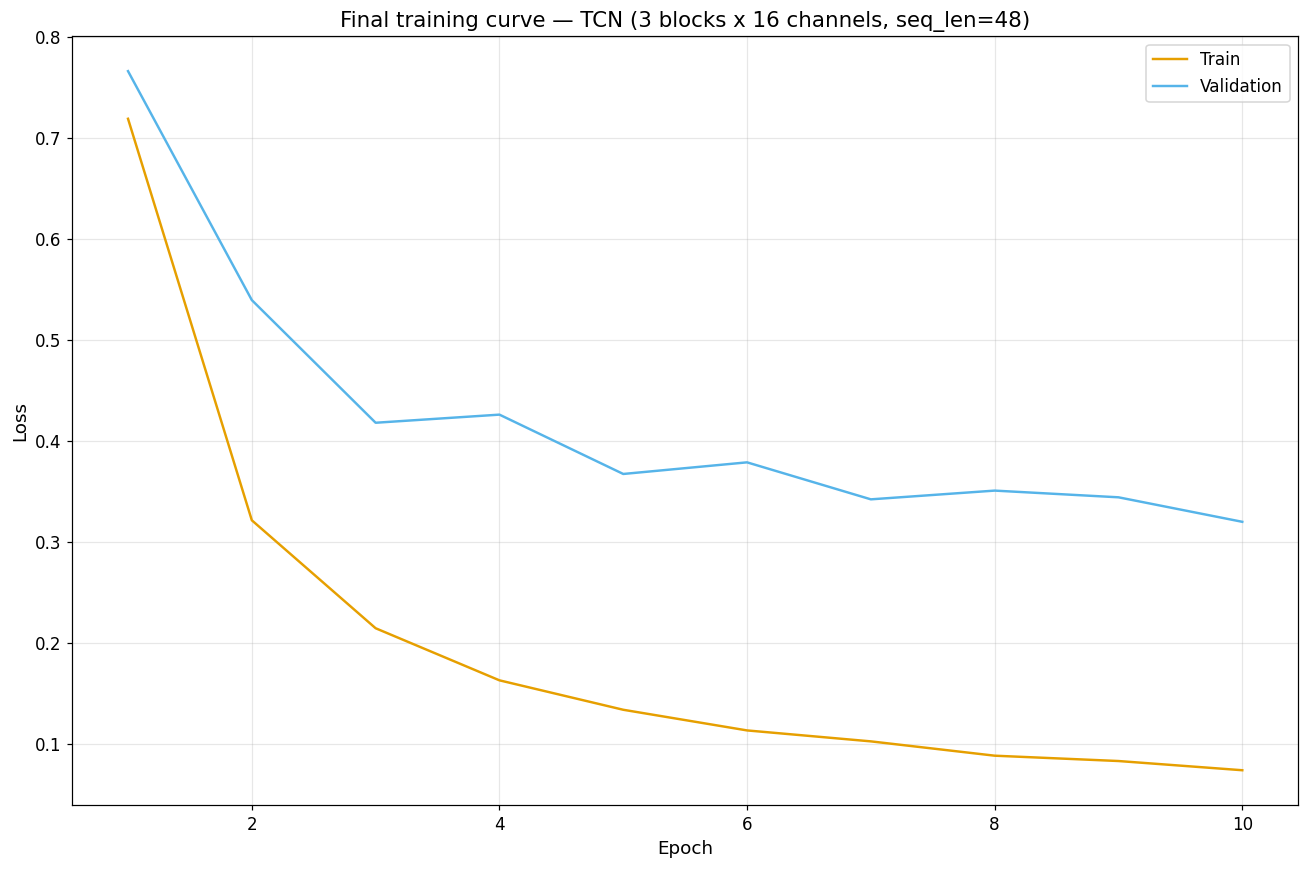

In [4]:
# T7 Cell 4 — Live train-vs-validation loss curve for the TCN.
# AC-2 evidence (training uses the Stage 10 harness — the shared
# ``run_training_loop`` extracted at T1) and demo-moment companion to
# the ablation table in Cell 6.

nn_t_cfg = NnTemporalConfig(
    target_column="nd_mw",
    feature_columns=tuple(feature_cols),
    seq_len=48,
    num_blocks=3,
    channels=16,
    kernel_size=3,
    dropout=0.0,
    weight_norm=False,
    learning_rate=1e-3,
    weight_decay=0.0,
    batch_size=64,
    max_epochs=10,
    patience=5,
    device="cpu",
)
nn_t_model = NnTemporalModel(nn_t_cfg)

handle = display(plt.figure(), display_id=True)
history: list[dict[str, float]] = []


def on_epoch(entry: dict[str, float]) -> None:
    history.append(entry)
    fig = plots.loss_curve(
        history,
        title=f"Training progress — epoch {int(entry['epoch'])}",
    )
    clear_output(wait=True)
    handle.update(fig)
    plt.close(fig)


t0 = time.time()
nn_t_model.fit(df_train[feature_cols], target_train, seed=0, epoch_callback=on_epoch)
elapsed = time.time() - t0
clear_output(wait=True)
print(f"NnTemporalModel.fit: {elapsed:.2f}s over {len(nn_t_model.loss_history_)} epoch(s).")
print(f"Best epoch: {nn_t_model.metadata.hyperparameters['best_epoch']} (early-stop restored).")
print(f"Device resolved: {nn_t_model.metadata.hyperparameters['device_resolved']}.")

fig = plots.loss_curve(
    nn_t_model.loss_history_,
    title="Final training curve — TCN (3 blocks x 16 channels, seq_len=48)",
)
fig.tight_layout()
plt.show()

## Register the temporal run (AC-4 round-trip evidence)

AC-4 says save / load through the registry must preserve full weights
*and* the sequence preprocessing state.  This cell exercises the save
half: compute the four holdout metrics from
`nn_t_model.predict(df_holdout[feature_cols])`, package them as a
one-row DataFrame, and call `registry.save` against the notebook
registry.  The load half is exercised in Cell 6 (the ablation table)
when the predict-only loop calls `registry.load(run_id)` to pull the
artefact back.

The cell is guarded by `registry.list_runs(model_type="nn_temporal", ...)`
so re-running the notebook does not produce duplicate runs.


In [5]:
# T7 Cell 5 — Register the TCN run (AC-4 save half).

existing_temporal = registry.list_runs(
    model_type="nn_temporal",
    target="nd_mw",
    registry_dir=NOTEBOOK_REGISTRY,
)
if existing_temporal:
    print(f"nn_temporal already registered: {existing_temporal[0]['run_id']}")
else:
    metrics_df = _holdout_metrics_df(nn_t_model, df_holdout[feature_cols])
    run_id = registry.save(
        nn_t_model,
        metrics_df,
        feature_set="weather_only",
        target="nd_mw",
        registry_dir=NOTEBOOK_REGISTRY,
    )
    print(f"nn_temporal registered: {run_id}")
    print()
    print("Holdout metrics (single-fold, plan D12):")
    _drop = ["fold_index", "train_end", "test_start", "test_end"]
    print(metrics_df.drop(columns=_drop).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

nn_temporal already registered: nn-temporal-b3-c16-k3_20260424T2331


## Ablation table — six families, predict-only (AC-3 + AC-5 + D10)

This is the canonical Stage 11 artefact named in intent §Demo moment.
One row per registered model family; all six rows scored on the same
holdout indices.  The cell is **predict-only** — for every registered
run it calls `registry.load(run["run_id"])`, then
`model.predict(df_holdout)` (with `df_holdout` carrying the full
feature frame so each model picks the columns it was fit on),
composes the four metrics (`mae`, `mape`, `rmse`, `wape`) inline, and
prints a markdown table sorted by MAE-ascending.

**No `model.fit` call appears in this cell.**  AC-5 forbids re-fitting
any registered run.  The plan's D11 cut (a standalone
`evaluation/ablation.py` helper) was made because this notebook-inline
loop is ~15 lines and binds no new public API; `compare_on_holdout`
internally re-fits per fold and is the wrong tool for AC-5.

Columns shipped: `run_id`, `model`, `mae`, `mape`, `rmse`, `wape`,
`fit_utc`.  Plan §1 D10 names a seven-column variant with
`MAE_ratio_vs_NESO`, `training_time_s`, and `param_count` — those three
are deferred at T7 (the first needs the NESO archive, the latter two
require sidecar fields that Stage 11 does not extend).  The closing
commentary cell surfaces the gap explicitly so a reader can see what
T8 might pick up.


In [6]:
# T7 Cell 6 — Ablation table.  Predict-only loop over every
# registered run; no ``model.fit`` call anywhere in this cell (AC-5).

ablation_rows = []
for run in registry.list_runs(registry_dir=NOTEBOOK_REGISTRY, sort_by=None):
    loaded = registry.load(run["run_id"], registry_dir=NOTEBOOK_REGISTRY)
    # Each model picks the columns it was fit on; pass the full
    # holdout frame so naive / sarimax / scipy_parametric / nn_mlp /
    # nn_temporal each find what they need.
    y_pred = loaded.predict(df_holdout)
    metrics = {fn.__name__: fn(target_holdout, y_pred) for fn in metric_fns}
    ablation_rows.append(
        {
            "run_id": run["run_id"],
            "model": run["type"],
            **metrics,
            "fit_utc": run["fit_utc"],
        }
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("mae").reset_index(drop=True)
print(f"Ablation: six families on the same holdout slice (>= {holdout_start})")
print()
# ``DataFrame.to_markdown`` requires the optional ``tabulate`` dep,
# which is not in this project's pyproject.toml; fall back to
# ``to_string`` which produces a fixed-width table that renders cleanly
# in Jupyter and the meetup projector.  The plan §1 D10 markdown
# rendering is a presentation choice, not a load-bearing AC.
print(ablation_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Ablation: six families on the same holdout slice (>= 2023-12-14 00:00:00+00:00)

                                    run_id            model        mae  mape       rmse  wape                          fit_utc
       nn-temporal-b3-c16-k3_20260424T2331      nn_temporal   3768.602 0.156   4565.988 0.139 2026-04-24T23:31:51.026006+00:00
naive-same-hour-same-weekday_20260424T2331            naive   4354.030 0.173   5467.694 0.161 2026-04-24T23:31:43.793670+00:00
              nn-mlp-relu-32_20260424T2331           nn_mlp   5241.125 0.221   6255.331 0.194 2026-04-24T23:31:48.184754+00:00
     linear-ols-weather-only_20260424T2331           linear   5347.787 0.227   6368.784 0.198 2026-04-24T23:31:43.894205+00:00
      sarimax-1-0-0-0-0-0-24_20260424T2331          sarimax  12334.669 0.437  13861.944 0.456 2026-04-24T23:31:44.986934+00:00
      scipy-parametric-d1-w1_20260424T2331 scipy_parametric 220249.883 8.719 242864.276 8.147 2026-04-24T23:31:45.031128+00:00


## Closing — the arc, the cut columns, what's next

**Reading the table.**  Every row bought us, or failed to buy us, some
accuracy on the same holdout indices.  The `naive` row is the
"how hard could it be?" floor.  The `linear` row is the "weather alone
gets you most of the way" lesson Stage 4 telegraphs.  `sarimax` adds
explicit time-series structure; `scipy_parametric` is the
domain-knowledge prior (heating / cooling degree-days).  `nn_mlp` is
Stage 10's MLP scaffold; `nn_temporal` is the new TCN with sequence
context.  The point of the stage is not necessarily that the TCN wins
— with the CPU recipe and ~1700 training rows it may not — but that
every model speaks through the same registry and the same predict
contract, so a Stage 12 serving stub can pick any of them by `run_id`
without a code change.

**Columns deferred from plan D10's seven-column spec** (surfaced for
T8 visibility, not silently cut):

- `MAE_ratio_vs_NESO` — requires the NESO archive (`bristol_ml.ingestion.neso_forecast.load`)
  and a warm cache; plus an alignment of the 30-minute NESO forecast
  to the hourly grid via `evaluation.benchmarks.align_half_hourly_to_hourly`.
  Out-of-band for T7's notebook scope; the Stage 4 benchmark CLI
  remains the canonical comparison surface.
- `training_time_s` and `param_count` — not in the registry sidecar at
  Stage 11.  Adding either requires a sidecar extension that the
  plan does not call for at T7.  A future stage that wants both
  could either extend `SidecarFields` or compute them at registration
  time inside each model's `metadata.hyperparameters` bag.

The ablation cell renders the table via `DataFrame.to_string` rather
than `DataFrame.to_markdown` because the optional `tabulate`
dependency is not in `pyproject.toml`; the plan's §1 D10 markdown
rendering is a presentation choice and `to_string` produces a
fixed-width table that renders cleanly in Jupyter and the meetup
projector.

**Stage 12 hook.**  The serving layer (`bristol_ml.serving`) lands
next.  Its job is to load any registered run by `run_id` via the same
four-verb registry surface and serve `predict(features)` calls — same
contract as the ablation cell, just behind a tiny HTTP / CLI veneer.
Six families, one verb.

- **Intent:** `docs/intent/11-complex-nn.md` (AC-1 through AC-5).
- **Plan:** `docs/plans/active/11-complex-nn.md` (moves to
  `completed/` at T8).
- **Next:** Stage 12 — serving (intent in `docs/intent/12-serving.md`
  when it lands).
